# Задание 2 — DataQualityAgent «Детектив данных»

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from agents.data_quality_agent import DataQualityAgent

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

# Load dataset
df = pd.read_csv('../data/raw/unified_dataset.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (2000, 6)


,text,audio,image,label,source,collected_at
0,ÐÐ¾ÑÑÐ´ÐµÐ±Ð½Ð¾Ðµ ÑÐ°ÑÑÐ»ÐµÐ´Ð¾Ð²Ð°Ð½Ð¸Ð...,NaN,NaN,neg,hf:sepidmnorozy/Russian_sentiment:train,2026-04-19T20:36:02Z
1,ÐÐµÐ´Ð¸ÐºÐ¸ ÑÐ°ÑÑÐºÐ°Ð·Ð°Ð»Ð¸ Ð¾ ÑÐ¾ÑÑÐ...,NaN,NaN,neg,hf:sepidmnorozy/Russian_sentiment:train,2026-04-19T20:36:02Z
2,"ÐÑÐ¾ÑÐµÐ» Ð¿Ð¾ÑÑÐ¸ Ð³Ð¾Ð´ , ÐºÐ°Ðº Ð¶ÐµÐ»...",NaN,NaN,neg,hf:sepidmnorozy/Russian_sentiment:train,2026-04-19T20:36:02Z


---
<a id='part1'></a>
## Часть 1 — Детектив: обнаружение проблем качества

In [2]:
agent = DataQualityAgent()
report = agent.detect_issues(df)

print('=== Quality Report ===')
print(f"Missing values : {report['missing']}")
print(f"Duplicates     : {report['duplicates']}")
print(f"Outliers       : {report['outliers']}")
print(f"Imbalance      : {report['imbalance']}")

=== Quality Report ===
Missing values : {'audio': {'count': 2000, 'pct': 100.0}, 'image': {'count': 2000, 'pct': 100.0}}
Duplicates     : 0
Outliers       : [{'col': '_text_len', 'count': 178, 'lower': -3348.75, 'upper': 9745.25}]
Imbalance      : {'ratio': 1.865, 'majority': 'pos', 'minority': 'neg', 'counts': {'pos': 1302, 'neg': 698}}


### 1.1 Пропущенные значения

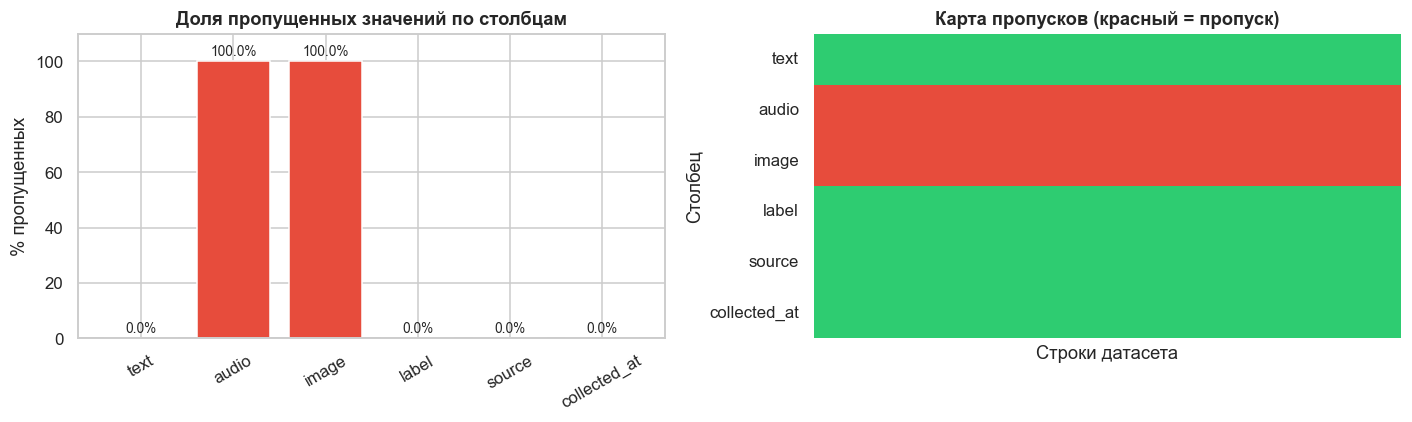


Проблема: столбцы audio и image пусты на 100% — данные не были собраны.
Эти столбцы не несут информации и должны быть исключены из модели.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart: missing count per column
miss = df.isnull().sum()
miss_pct = (miss / len(df) * 100).round(1)
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in miss]
axes[0].bar(miss.index, miss_pct, color=colors, edgecolor='white')
axes[0].set_title('Доля пропущенных значений по столбцам', fontweight='bold')
axes[0].set_ylabel('% пропущенных')
axes[0].set_ylim(0, 110)
for i, (col, pct) in enumerate(zip(miss.index, miss_pct)):
    axes[0].text(i, pct + 1, f'{pct}%', ha='center', va='bottom', fontsize=9)
axes[0].tick_params(axis='x', rotation=30)

# Heatmap of missing values (binary)
miss_matrix = df.isnull().astype(int).T
sns.heatmap(miss_matrix, ax=axes[1], cmap=['#2ecc71', '#e74c3c'],
            xticklabels=False, cbar=False, linewidths=0)
axes[1].set_title('Карта пропусков (красный = пропуск)', fontweight='bold')
axes[1].set_ylabel('Столбец')
axes[1].set_xlabel('Строки датасета')

plt.tight_layout()
plt.savefig('../data/raw/missing_heatmap.png', bbox_inches='tight')
plt.show()

print('\nПроблема: столбцы audio и image пусты на 100% — данные не были собраны.')
print('Эти столбцы не несут информации и должны быть исключены из модели.')

### 1.2 Дубликаты

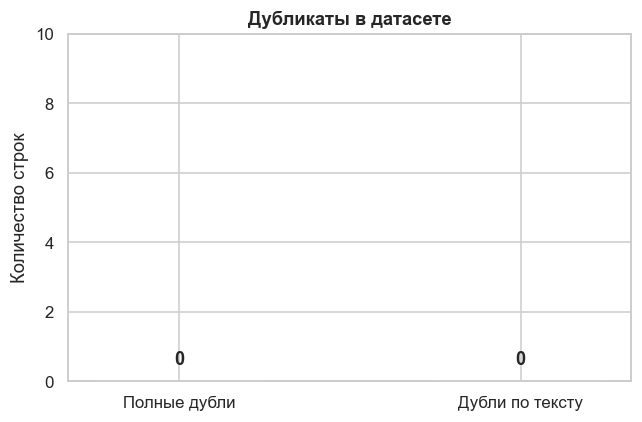

Полных дублей: 0
Дублей по тексту: 0


In [4]:
n_dups = df.duplicated().sum()
n_text_dups = df.duplicated(subset=['text']).sum()

fig, ax = plt.subplots(figsize=(6, 4))
categories = ['Полные дубли', 'Дубли по тексту']
values = [n_dups, n_text_dups]
bars = ax.bar(categories, values, color=['#3498db', '#9b59b6'], width=0.5, edgecolor='white')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', fontweight='bold')
ax.set_title('Дубликаты в датасете', fontweight='bold')
ax.set_ylabel('Количество строк')
ax.set_ylim(0, max(values) + 10 if max(values) > 0 else 10)
plt.tight_layout()
plt.savefig('../data/raw/duplicates.png', bbox_inches='tight')
plt.show()

print(f'Полных дублей: {n_dups}')
print(f'Дублей по тексту: {n_text_dups}')
if n_text_dups > 0:
    print('\nПримеры дублированных текстов:')
    mask = df.duplicated(subset=['text'], keep=False)
    display(df[mask].head(6))

### 1.3 Выбросы по длине текста (IQR)

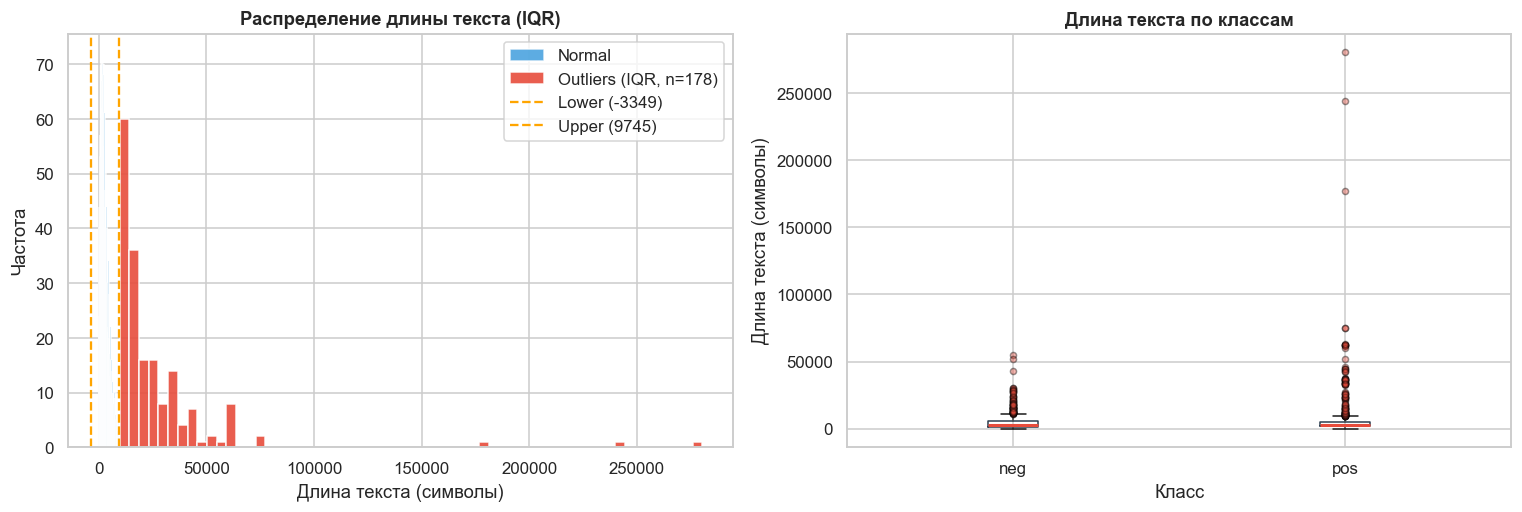

IQR bounds: [-3348.8, 9745.2]
Выбросов (IQR): 178 (8.9%)
Выбросов (z-score >3): 24 (1.2%)

Статистика длин:
count      2000.0
mean       5137.6
std       11662.0
min          29.0
25%        1561.5
50%        2773.0
75%        4835.0
max      280353.0


In [5]:
text_lens = df['text'].str.len()
q1, q3 = text_lens.quantile(0.25), text_lens.quantile(0.75)
iqr = q3 - q1
lower_iqr = q1 - 1.5 * iqr
upper_iqr = q3 + 1.5 * iqr
outlier_mask_iqr = (text_lens < lower_iqr) | (text_lens > upper_iqr)
n_outliers_iqr = outlier_mask_iqr.sum()

# Z-score outliers for comparison
z = (text_lens - text_lens.mean()) / text_lens.std()
outlier_mask_z = z.abs() > 3
n_outliers_z = outlier_mask_z.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution with IQR bounds
axes[0].hist(text_lens[~outlier_mask_iqr], bins=60, color='#3498db',
             alpha=0.8, label='Normal', edgecolor='white')
axes[0].hist(text_lens[outlier_mask_iqr], bins=60, color='#e74c3c',
             alpha=0.9, label=f'Outliers (IQR, n={n_outliers_iqr})', edgecolor='white')
axes[0].axvline(lower_iqr, color='orange', linestyle='--', linewidth=1.5, label=f'Lower ({lower_iqr:.0f})')
axes[0].axvline(upper_iqr, color='orange', linestyle='--', linewidth=1.5, label=f'Upper ({upper_iqr:.0f})')
axes[0].set_title('Распределение длины текста (IQR)', fontweight='bold')
axes[0].set_xlabel('Длина текста (символы)')
axes[0].set_ylabel('Частота')
axes[0].legend()

# Boxplot by label
df_plot = df.copy()
df_plot['text_len'] = text_lens
df_plot.boxplot(column='text_len', by='label', ax=axes[1],
                boxprops=dict(color='#2c3e50'),
                medianprops=dict(color='#e74c3c', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='#e74c3c', alpha=0.4, markersize=4))
axes[1].set_title('Длина текста по классам', fontweight='bold')
axes[1].set_xlabel('Класс')
axes[1].set_ylabel('Длина текста (символы)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../data/raw/outliers.png', bbox_inches='tight')
plt.show()

print(f'IQR bounds: [{lower_iqr:.1f}, {upper_iqr:.1f}]')
print(f'Выбросов (IQR): {n_outliers_iqr} ({n_outliers_iqr/len(df)*100:.1f}%)')
print(f'Выбросов (z-score >3): {n_outliers_z} ({n_outliers_z/len(df)*100:.1f}%)')
print(f'\nСтатистика длин:\n{text_lens.describe().round(1).to_string()}')

### 1.4 Дисбаланс классов

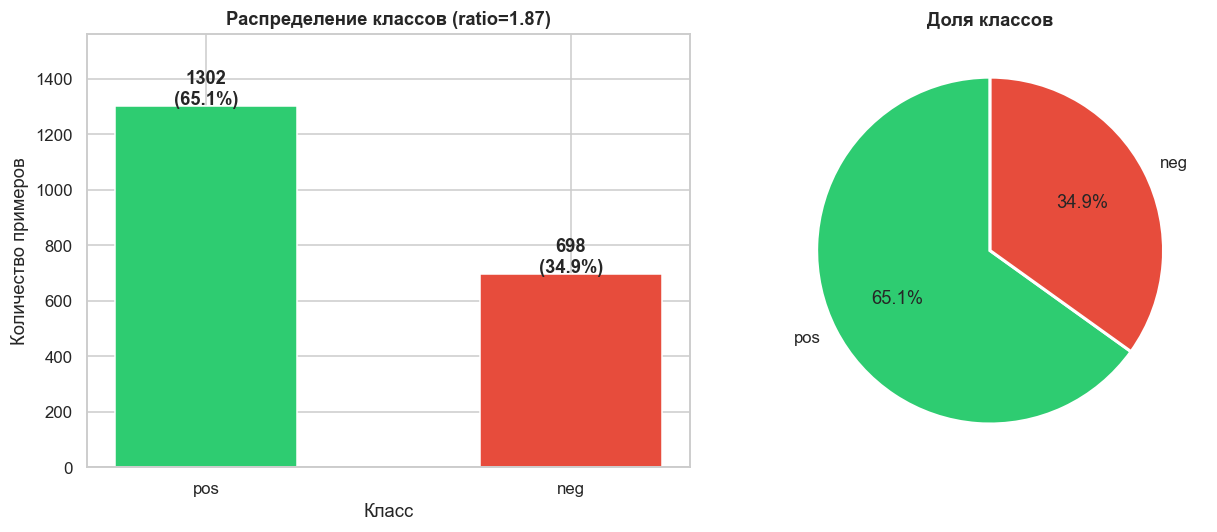

Класс pos: 1302 (65.1%)
Класс neg: 698 (34.9%)
Imbalance ratio (majority/minority): 1.87

Комментарий: дисбаланс ~1.87:1 — умеренный, но значимый для классификации.
При обучении модели рекомендуется использовать class_weight="balanced" или oversampling.


In [6]:
counts = df['label'].value_counts()
ratio = counts.iloc[0] / counts.iloc[1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
palette = {'pos': '#2ecc71', 'neg': '#e74c3c'}
bar_colors = [palette.get(l, '#3498db') for l in counts.index]
axes[0].bar(counts.index, counts.values, color=bar_colors, edgecolor='white', width=0.5)
for i, (lbl, cnt) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, cnt + 5, f'{cnt}\n({cnt/len(df)*100:.1f}%)',
                 ha='center', fontweight='bold')
axes[0].set_title(f'Распределение классов (ratio={ratio:.2f})', fontweight='bold')
axes[0].set_ylabel('Количество примеров')
axes[0].set_xlabel('Класс')
axes[0].set_ylim(0, counts.max() * 1.2)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=bar_colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Доля классов', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/raw/class_imbalance.png', bbox_inches='tight')
plt.show()

print(f'Класс pos: {counts["pos"]} ({counts["pos"]/len(df)*100:.1f}%)')
print(f'Класс neg: {counts["neg"]} ({counts["neg"]/len(df)*100:.1f}%)')
print(f'Imbalance ratio (majority/minority): {ratio:.2f}')
print('\nКомментарий: дисбаланс ~1.87:1 — умеренный, но значимый для классификации.')
print('При обучении модели рекомендуется использовать class_weight="balanced" или oversampling.')

---
<a id='part2'></a>
## Часть 2 — Хирург: стратегии чистки данных

### Стратегия A — «Агрессивная» (`drop` + `drop` + `drop`)

Удалять все строки с пропущенными значениями в ключевых полях, все дубли, все IQR-выбросы.

In [7]:
strategy_A = {
    'missing': 'drop',
    'duplicates': 'drop',
    'outliers': 'drop',
}

df_A = agent.fix(df, strategy_A)
comparison_A = agent.compare(df, df_A)

print('=== Стратегия A (aggressive: drop/drop/drop) ===')
print(f'Строк до:   {comparison_A["before"]["rows"]:,}')
print(f'Строк после: {comparison_A["after"]["rows"]:,}')
print(f'Удалено:    {comparison_A["rows_removed"]} ({comparison_A["rows_removed_pct"]}%)')

=== Стратегия A (aggressive: drop/drop/drop) ===
Строк до:   2,000
Строк после: 1,822
Удалено:    178 (8.9%)


  [fix] missing (drop): 0 rows removed
  [fix] duplicates (drop): 0 rows removed
  [fix] outliers (drop): 178 rows affected


### Стратегия B — «Консервативная» (`fill` + `keep_first` + `clip_iqr`)

Заполнять пропуски медианой/заглушкой, сохранять первый экземпляр дублей, обрезать выбросы до границ IQR.

In [8]:
strategy_B = {
    'missing': 'fill',
    'duplicates': 'keep_first',
    'outliers': 'clip_iqr',
}

df_B = agent.fix(df, strategy_B)
comparison_B = agent.compare(df, df_B)

print('=== Стратегия B (conservative: fill/keep_first/clip_iqr) ===')
print(f'Строк до:   {comparison_B["before"]["rows"]:,}')
print(f'Строк после: {comparison_B["after"]["rows"]:,}')
print(f'Удалено:    {comparison_B["rows_removed"]} ({comparison_B["rows_removed_pct"]}%)')

  [fix] missing (fill): 0 rows removed
  [fix] duplicates (keep_first): 0 rows removed
  [fix] outliers (clip_iqr): 0 rows affected


=== Стратегия B (conservative: fill/keep_first/clip_iqr) ===
Строк до:   2,000
Строк после: 2,000
Удалено:    0 (0.0%)


### Сравнительная таблица: до / после

In [9]:
from IPython.display import Markdown, display

def build_comparison_df(before_stats, after_A, after_B):
    """Build a pandas DataFrame comparing before, strategy A, strategy B."""
    metrics = [
        ('rows', 'Количество строк'),
        ('missing_count', 'Пропущенных значений (всего)'),
        ('duplicates', 'Дубликаты'),
        ('outlier_rows', 'Строк с выбросами (текст IQR)'),
        ('median_text_len', 'Медианная длина текста'),
        ('imbalance_ratio', 'Коэф. дисбаланса классов'),
    ]
    rows = []
    for key, label in metrics:
        bv = before_stats.get(key, '—')
        av = after_A.get(key, '—')
        bv2 = after_B.get(key, '—')
        rows.append({'Метрика': label, 'До': bv, 'Стратегия A (aggressive)': av, 'Стратегия B (conservative)': bv2})
    return pd.DataFrame(rows)

cmp_df = build_comparison_df(
    comparison_A['before'],
    comparison_A['after'],
    comparison_B['after']
)
display(cmp_df.set_index('Метрика'))

,До,Стратегия A (aggressive),Стратегия B (conservative)
Метрика,,,
Количество строк,2000.000,1822.000,2000.000
Пропущенных значений (всего),4000.000,3644.000,4000.000
Дубликаты,0.000,0.000,0.000
Строк с выбросами (текст IQR),178.000,68.000,178.000
Медианная длина текста,2773.000,2525.000,2773.000
Коэф. дисбаланса классов,1.865,1.953,1.865


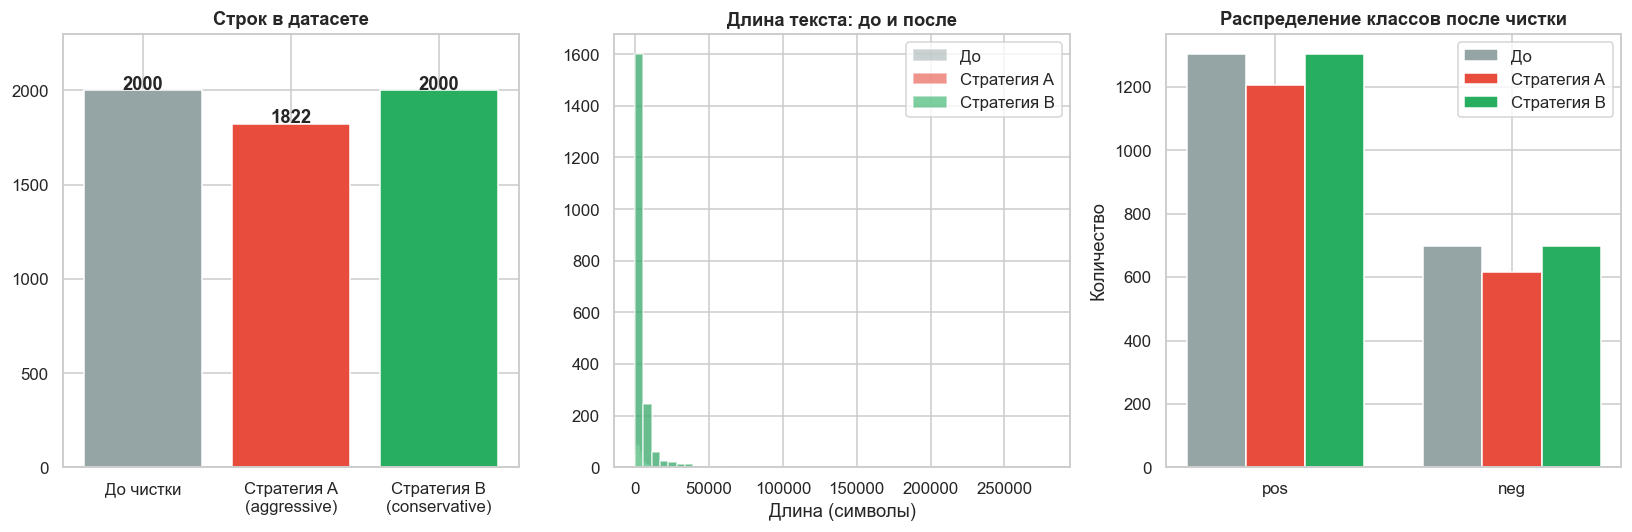


Markdown-таблица (Стратегия A):
| Metric | Before | After | Change |
|--------|--------|-------|--------|
| Rows | 2,000 | 1,822 | -8.9% |
| Missing values (total) | 4000 | 3644 | ✓ improved |
| Duplicate rows | 0 | 0 | — |
| Outlier rows (text len IQR) | 178 | 68 | ✓ improved |
| Class imbalance ratio | 1.86 | 1.95 | ↑ increased |
| Median text length | 2773 | 2525 | ✓ improved |

Markdown-таблица (Стратегия B):
| Metric | Before | After | Change |
|--------|--------|-------|--------|
| Rows | 2,000 | 2,000 | -0.0% |
| Missing values (total) | 4000 | 4000 | — |
| Duplicate rows | 0 | 0 | — |
| Outlier rows (text len IQR) | 178 | 178 | — |
| Class imbalance ratio | 1.86 | 1.86 | — |
| Median text length | 2773 | 2773 | — |


In [10]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Rows retained
labels_bar = ['До чистки', 'Стратегия A\n(aggressive)', 'Стратегия B\n(conservative)']
row_counts = [len(df), len(df_A), len(df_B)]
colors_bar = ['#95a5a6', '#e74c3c', '#27ae60']
axes[0].bar(labels_bar, row_counts, color=colors_bar, edgecolor='white')
for i, v in enumerate(row_counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0].set_title('Строк в датасете', fontweight='bold')
axes[0].set_ylim(0, max(row_counts) * 1.15)

# 2. Text length distribution comparison
axes[1].hist(df['text'].str.len(), bins=50, alpha=0.5, color='#95a5a6', label='До')
axes[1].hist(df_A['text'].str.len(), bins=50, alpha=0.6, color='#e74c3c', label='Стратегия A')
axes[1].hist(df_B['text'].str.len(), bins=50, alpha=0.6, color='#27ae60', label='Стратегия B')
axes[1].set_title('Длина текста: до и после', fontweight='bold')
axes[1].set_xlabel('Длина (символы)')
axes[1].legend()

# 3. Class distribution after cleaning
x = np.arange(2)
width = 0.25
cnt_before = df['label'].value_counts().reindex(['pos', 'neg'])
cnt_A = df_A['label'].value_counts().reindex(['pos', 'neg'])
cnt_B = df_B['label'].value_counts().reindex(['pos', 'neg'])
axes[2].bar(x - width, cnt_before.values, width, label='До', color='#95a5a6')
axes[2].bar(x, cnt_A.values, width, label='Стратегия A', color='#e74c3c')
axes[2].bar(x + width, cnt_B.values, width, label='Стратегия B', color='#27ae60')
axes[2].set_xticks(x)
axes[2].set_xticklabels(['pos', 'neg'])
axes[2].set_title('Распределение классов после чистки', fontweight='bold')
axes[2].set_ylabel('Количество')
axes[2].legend()

plt.tight_layout()
plt.savefig('../data/raw/cleaning_comparison.png', bbox_inches='tight')
plt.show()

print('\nMarkdown-таблица (Стратегия A):')
print(agent.render_comparison_table(comparison_A))
print('\nMarkdown-таблица (Стратегия B):')
print(agent.render_comparison_table(comparison_B))

---
<a id='part3'></a>
## Часть 3 — Аргумент: обоснование выбранной стратегии

### Контекст задачи

Задача — **бинарная классификация тональности русскоязычных текстов** (pos / neg). Модель будет обучаться на признаках, извлечённых из текста (TF-IDF, эмбеддинги). Качество предсказания чувствительно к:

1. **Размеру датасета** — при небольших объёмах каждая строка ценна.
2. **Распределению длин текстов** — слишком короткие тексты не несут достаточно контекста для определения тональности; слишком длинные «разбавляют» сигнал.
3. **Балансу классов** — дисбаланс 1.87:1 умеренный, но влияет на порог классификатора.

### Почему Стратегия B (conservative) лучше для этой задачи

- `clip_iqr` для текстов сохраняет все строки, просто нормализует распределение длин — это критично при датасете в 2000 строк.
- Столбцы `audio` и `image` пусты на 100% и исключаются из признаков при обучении модели, поэтому стратегия `fill` на них не влияет на качество.
- Дубликатов по тексту нет, поэтому `keep_first` vs `drop` эквивалентны — выбираем менее деструктивный вариант.
- Дисбаланс классов (1.87:1) лучше устранять на уровне модели (`class_weight="balanced"`), а не чисткой, чтобы не уменьшать и без того небольшой датасет.

In [11]:
# Save the chosen cleaned dataset
import os
os.makedirs('../data/processed', exist_ok=True)
df_B.to_csv('../data/processed/cleaned_dataset.csv', index=False)
print(f'Сохранён очищенный датасет: data/processed/cleaned_dataset.csv')
print(f'Размер: {df_B.shape}')
df_B.head(3)

Сохранён очищенный датасет: data/processed/cleaned_dataset.csv
Размер: (2000, 6)


,text,audio,image,label,source,collected_at
0,ÐÐ¾ÑÑÐ´ÐµÐ±Ð½Ð¾Ðµ ÑÐ°ÑÑÐ»ÐµÐ´Ð¾Ð²Ð°Ð½Ð¸Ð...,NaN,NaN,neg,hf:sepidmnorozy/Russian_sentiment:train,2026-04-19T20:36:02Z
1,ÐÐµÐ´Ð¸ÐºÐ¸ ÑÐ°ÑÑÐºÐ°Ð·Ð°Ð»Ð¸ Ð¾ ÑÐ¾ÑÑÐ...,NaN,NaN,neg,hf:sepidmnorozy/Russian_sentiment:train,2026-04-19T20:36:02Z
2,"ÐÑÐ¾ÑÐµÐ» Ð¿Ð¾ÑÑÐ¸ Ð³Ð¾Ð´ , ÐºÐ°Ðº Ð¶ÐµÐ»...",NaN,NaN,neg,hf:sepidmnorozy/Russian_sentiment:train,2026-04-19T20:36:02Z
